In [ ]:
################################
##                            ##
##          INSTALL           ##
##                            ##
################################

In [ ]:
!pip install pmdarima numpy==1.26.4
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [ ]:
############################
##          DATA          ##
############################

In [ ]:
# ---------------------------
# กำหนดค่า seed ให้เหมือนกันทุกครั้ง
# ---------------------------
import tensorflow as tf
import random
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

             Price
Date              
2022-01-03  399.93
2022-01-04  383.20
2022-01-05  362.71
2022-01-06  354.90
2022-01-07  342.32


<Figure size 1000x600 with 0 Axes>

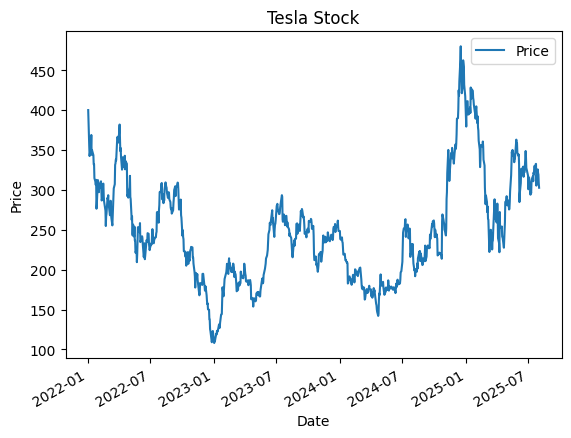

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
url = "Tesla Stock Price History.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)
df = df.sort_index()

# ดูข้อมูลเบื้องต้น
print(df.head())

# พล็อตข้อมูล
plt.figure(figsize=(10, 6))
df.plot()
plt.title("Tesla Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

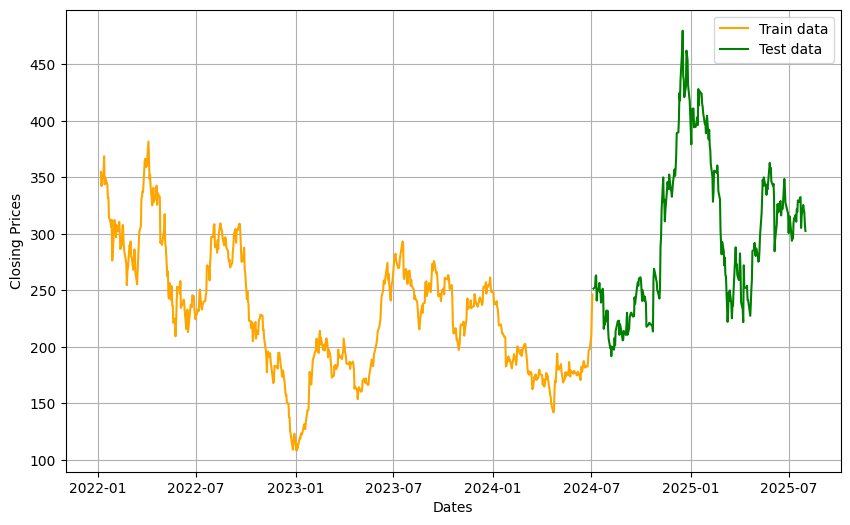

In [ ]:
train_data, test_data = df['Price'][3:int(len(df['Price'])*0.7)] , df['Price'][int(len(df['Price'])*0.7):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_data, 'orange', label='Train data')
plt.plot(test_data, 'green', label='Test data')
plt.legend()

In [ ]:
#---------------
# คำนวณ error
#---------------

def cal_error(train , train_pred , test , test_pred):
  from math import sqrt
  import numpy as np
  from sklearn.metrics import mean_squared_error, mean_absolute_error
  # ---------------------------
  # คำนวณค่า RMSE, MAE, MAPE
  # ---------------------------
  train_rmse = sqrt(mean_squared_error(train, train_pred))
  test_rmse = sqrt(mean_squared_error(test, test_pred))

  train_mae = mean_absolute_error(train, train_pred)
  test_mae = mean_absolute_error(test, test_pred)

  train_mape = np.mean(np.abs((train - train_pred) / train)) * 100
  test_mape = np.mean(np.abs((test - test_pred) / test)) * 100

  print(f"Train --> RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}, MAPE: {train_mape:.2f}%")
  print(f"Test --> RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}, MAPE: {test_mape:.2f}%")

In [ ]:
# สร้าง formatter สำหรับปี พ.ศ.
def format_thai_date(x, pos=None):
    date = mdates.num2date(x)
    thai_year = date.year + 543
    return f"{date.day:02d}/{date.month:02d}/{thai_year}"

In [ ]:
##################################
##                              ##
##          Box-Jenkins         ##
##                              ##
##################################

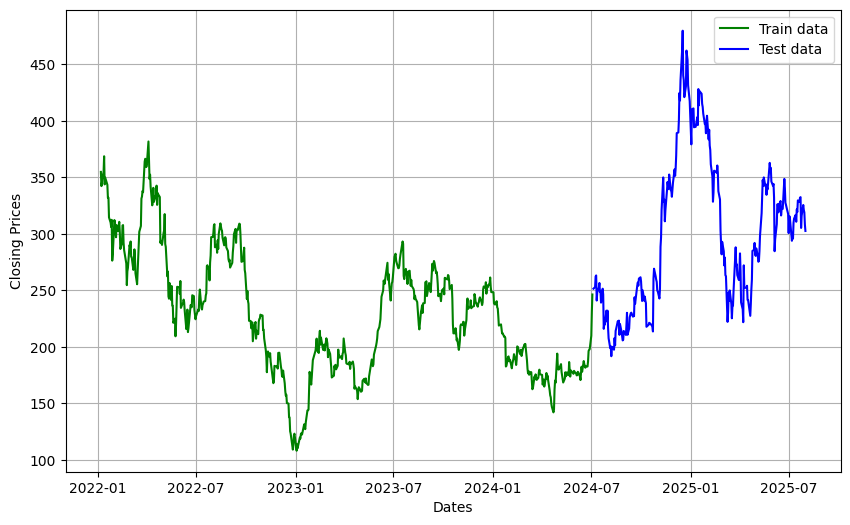

In [ ]:
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_data , 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

Mode = additive
  Seasonal variance / Residual variance → used for strength check


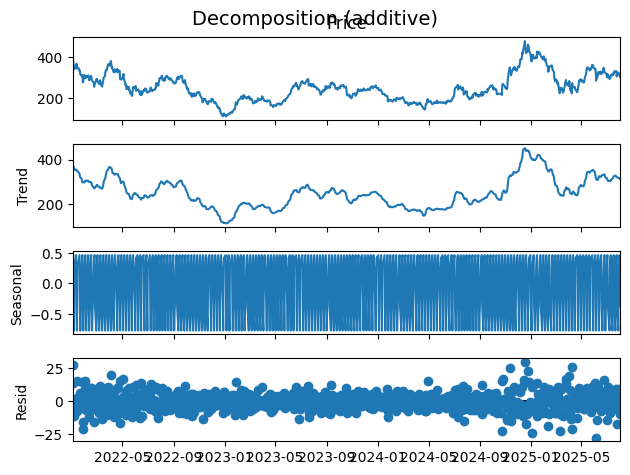

Strength (additive): 0.005540642929694806


In [ ]:
#---------------------------------
#   ทดสอบ Trend , Seasonal
#---------------------------------

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


def decompose_and_plot(series, mode, period=252):
    res = seasonal_decompose(series, model=mode, period=period, extrapolate_trend='freq')
    print(f"Mode = {mode}")
    print("  Seasonal variance / Residual variance → used for strength check")
    res.plot()
    plt.suptitle(f"Decomposition ({mode})", fontsize=14)
    plt.show()
    return res

# Drop missing values from MSFT_close
df_cleaned = df['Price'].dropna()

# ทดลองทั้งสองแบบ
res_add = decompose_and_plot(df_cleaned, mode='additive', period=5)

# คำนวณ seasonal strength แบบ additive
def seasonal_strength(res):
    resid = res.resid.dropna()
    seasonal = res.seasonal.dropna()
    denom = (resid + seasonal).var()
    if denom == 0:
        return np.nan
    return 1 - (resid.var() / denom)

print("Strength (additive):", seasonal_strength(res_add))

#--------------------------------------
#  ใช้วิธี Additive
#--------------------------------------

result = seasonal_decompose(df_cleaned, model='additive', period=5)

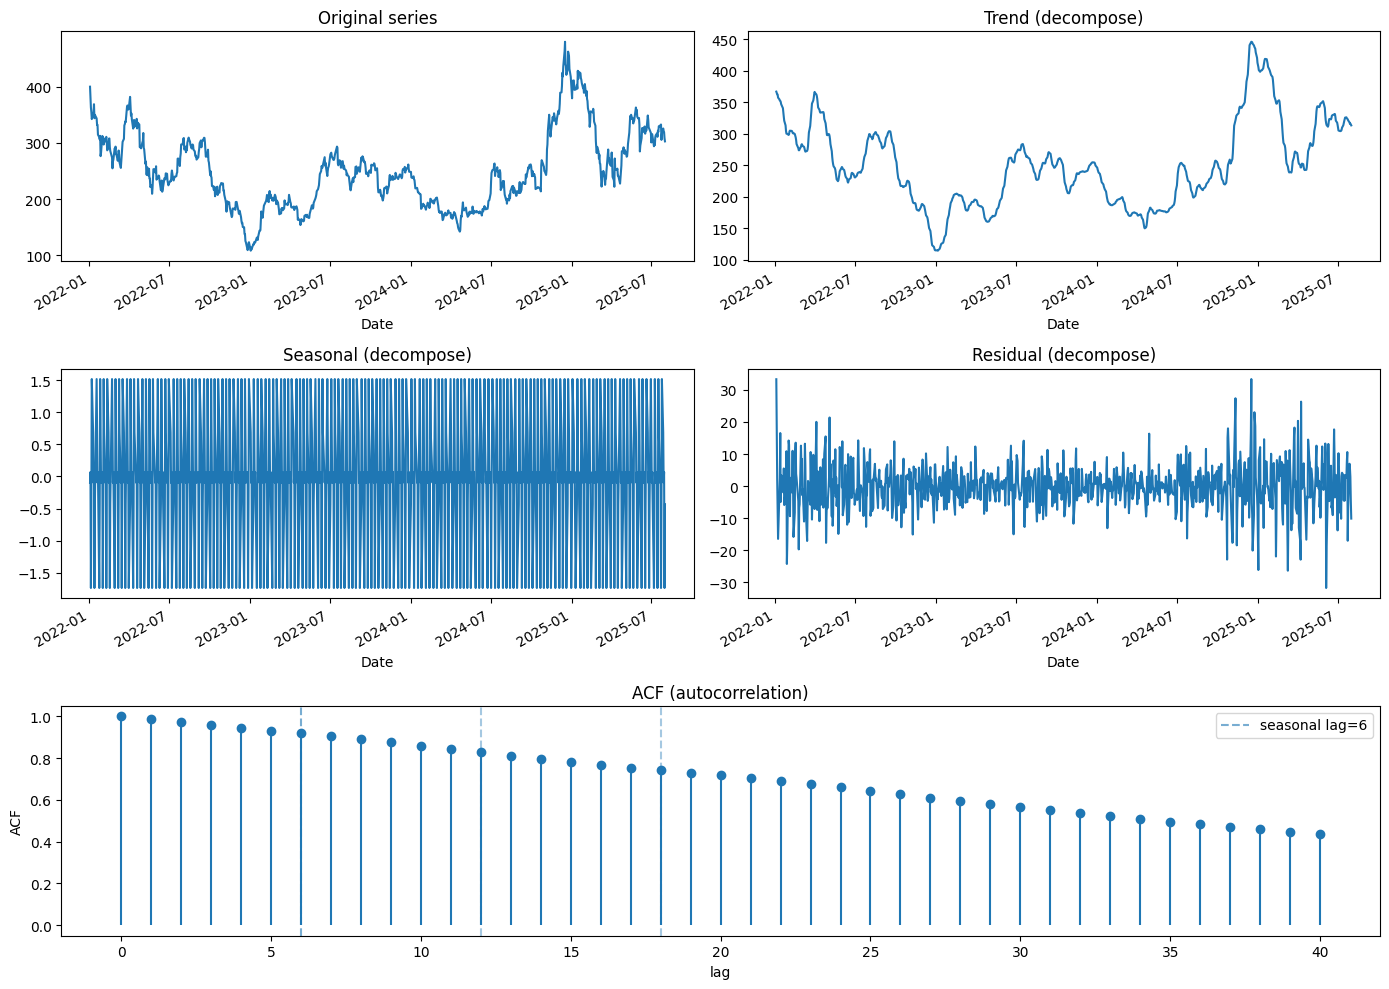

Ljung-Box: significant autocorrelation at lag=6 (p=0)\nLjung-Box: significant autocorrelation at lag=12 (p=0)\nLjung-Box: significant autocorrelation at lag=18 (p=0)\nKruskal-Wallis: no evidence groups differ (p=1)


In [ ]:
# โค้ดตัวอย่าง: ตรวจสอบ seasonality (visual + ACF + Ljung-Box + Kruskal-Wallis)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import kruskal

def test_seasonality(series, m=12, max_seasonal_multiples=3, plot=True):
    """
    series: pandas Series with DatetimeIndex (หรือ Index ใดก็ได้ แต่ต้องมีลำดับเวลา)
    m: seasonal period (ตัวอย่าง: 12=รายเดือน, 4=รายไตรมาส, 7=รายสัปดาห์)
    max_seasonal_multiples: จะทดสอบ Ljung-Box ที่ lags = m, 2m, ... จนถึง max_seasonal_multiples*m
    คืนค่า: dict สรุปผลทดสอบ
    """
    # เช็คและเตรียม
    s = series.dropna().astype(float)
    if len(s) < max(2*m, 20):
        print("เตือน: series สั้นเกินไป ผลทดสอบอาจไม่แม่น")

    results = {}

    # 1) Seasonal decomposition (additive ถ้าไม่แน่ใจ)
    try:
        dec = seasonal_decompose(s, period=m, model='additive', extrapolate_trend='freq')
        results['decompose'] = dec
    except Exception as e:
        results['decompose'] = None
        print("ไม่สามารถทำ seasonal_decompose ได้:", e)

    # 2) ACF — ดู autocorr ที่ lag หลัก
    nlags = max(3*m, 40)
    acf_vals = acf(s, nlags=nlags, fft=True)
    results['acf'] = (acf_vals, nlags)

    # 3) Ljung-Box at seasonal lags (m, 2m, ...)
    ljung = {}
    lags_to_test = [m * i for i in range(1, max_seasonal_multiples+1)]
    # acorr_ljungbox takes list/array of lags (we use return_df for convenience)
    lb = acorr_ljungbox(s, lags=lags_to_test, return_df=True)
    # lb has columns lb_stat, lb_pvalue
    for lag in lags_to_test:
        ljung[lag] = {'lb_stat': float(lb.loc[lag, 'lb_stat']), 'pvalue': float(lb.loc[lag, 'lb_pvalue'])}
    results['ljung_box'] = ljung

    # 4) Kruskal-Wallis: แบ่งกลุ่มตามตำแหน่งฤดูกาล (0..m-1)
    pos = np.arange(len(s)) % m
    groups = [s.values[pos == i] for i in range(m) if np.sum(pos==i) > 0]
    # ถ้ากลุ่มน้อยกว่า 2 จะไม่สามารถทดสอบได้
    if len(groups) >= 2:
        kw_stat, kw_p = kruskal(*groups)
        results['kruskal'] = {'statistic': float(kw_stat), 'pvalue': float(kw_p)}
    else:
        results['kruskal'] = None

    # Plot (optional)
    if plot:
        plt.figure(figsize=(14,10))
        ax1 = plt.subplot(321)
        s.plot(ax=ax1, title='Original series')
        ax2 = plt.subplot(322)
        if results['decompose'] is not None:
            results['decompose'].trend.plot(ax=ax2, title='Trend (decompose)')
        else:
            ax2.text(0.5, 0.5, 'No decomposition', ha='center')
        ax3 = plt.subplot(323)
        if results['decompose'] is not None:
            results['decompose'].seasonal.plot(ax=ax3, title='Seasonal (decompose)')
        ax4 = plt.subplot(324)
        if results['decompose'] is not None:
            results['decompose'].resid.plot(ax=ax4, title='Residual (decompose)')
        ax5 = plt.subplot(313)
        # plot acf points (simple)
        lags = np.arange(len(acf_vals))
        plt.stem(lags, acf_vals, basefmt=" ")
        plt.axvline(m, linestyle='--', alpha=0.6, label=f'seasonal lag={m}')
        for i in range(2, max_seasonal_multiples+1):
            plt.axvline(i*m, linestyle='--', alpha=0.4)
        plt.title('ACF (autocorrelation)')
        plt.xlabel('lag')
        plt.ylabel('ACF')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # สรุปการตีความแบบง่าย
    interp = []
    # Ljung-Box: ถ้า pvalue เล็ก (เช่น <0.05) ที่ lag = m หรือหลายๆ multiple แสดงการมี autocorr ที่ฤดูกาล
    for lag, info in ljung.items():
        if info['pvalue'] < 0.05:
            interp.append(f"Ljung-Box: significant autocorrelation at lag={lag} (p={info['pvalue']:.3g})")
        else:
            interp.append(f"Ljung-Box: no significant autocorr at lag={lag} (p={info['pvalue']:.3g})")
    # Kruskal
    if results['kruskal'] is not None:
        if results['kruskal']['pvalue'] < 0.05:
            interp.append(f"Kruskal-Wallis: month/season groups differ (p={results['kruskal']['pvalue']:.3g}) → evidence of seasonality")
        else:
            interp.append(f"Kruskal-Wallis: no evidence groups differ (p={results['kruskal']['pvalue']:.3g})")
    else:
        interp.append("Kruskal-Wallis: ไม่สามารถทดสอบได้ (กลุ่มน้อยเกินไป)")

    results['interpretation'] = interp
    return results


df.index = pd.to_datetime(df.index)
series = df['Price']
out = test_seasonality(series, m=6)
print('\\n'.join(out['interpretation']))

In [ ]:
from scipy.stats import linregress
df_cal =df_cleaned
t = np.arange(len(df_cal))

result_linear = linregress(t,df_cal)
print(f"Slope: {result_linear.slope}")
print(f"p-value: {result_linear.pvalue}")

TypeError: 'LinregressResult' object is not callable

In [ ]:
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress

df_cal = df_cleaned

# ลองเช็ค
for d in range(2):
  t = np.arange(len(df_cal))
  result = adfuller(df_cal)
  result_kpss = kpss(df_cal, regression = 'ct')
  result_linear = linregress(t, df_cal)

  if result[1] <= 0.05:
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("KPSS Statistic:", result_kpss[0])
    print("p-value:", result_kpss[1])
    print("Slope:", result_linear[0])
    print("p-value:", result_linear[3])
    print('Stationary')
    print('d =',d)
    break
  else:
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("KPSS Statistic:", result_kpss[0])
    print("p-value:", result_kpss[1])
    print("Slope:", result_linear[0])
    print("p-value:", result_linear[3])
    df_cal = np.log(df_cleaned)
    df_cal = df_cal.diff().dropna()
    print('Non stationary')

ADF Statistic: -2.7459166159583632
p-value: 0.06642409353255616
KPSS Statistic: 0.5591706074070594
p-value: 0.01
Slope: 0.04789943958757248
p-value: 1.737924467713544e-08
Non stationary
ADF Statistic: -8.45486736383307
p-value: 1.6250941552689203e-13
KPSS Statistic: 0.041960619111722504
p-value: 0.1
Slope: 5.462328719826657e-06
p-value: 0.28829108917874513
Stationary
d = 1


/tmp/ipython-input-3638192293.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(df_cal, regression = 'ct')
/tmp/ipython-input-3638192293.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(df_cal, regression = 'ct')


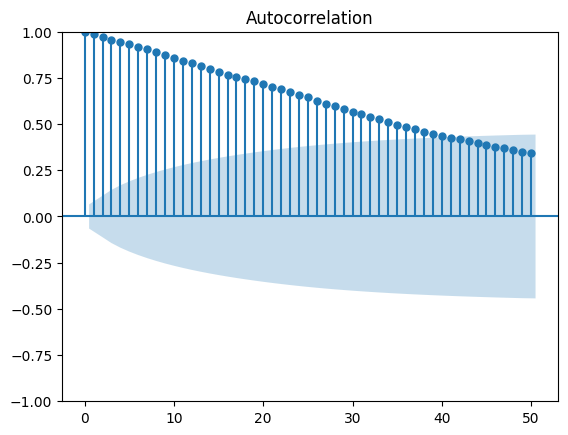

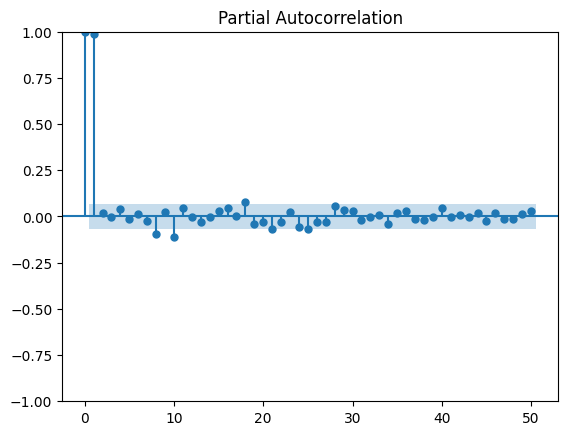

In [ ]:
#-------------------------
#   กราฟ ACF , PACF
#-------------------------

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Price'],lags=50)
plot_pacf(df['Price'],lags=50)
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=4460.210, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=4460.858, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=4462.415, Time=0.38 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=4462.035, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=4459.113, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=4460.650, Time=0.22 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=4457.017, Time=0.61 sec
 ARIMA(0,1,0)(2,0,1)[5] intercept   : AIC=4459.175, Time=0.78 sec
 ARIMA(0,1,0)(1,0,2)[5] intercept   : AIC=4459.392, Time=0.95 sec
 ARIMA(0,1,0)(0,0,2)[5] intercept   : AIC=4458.156, Time=1.06 sec
 ARIMA(0,1,0)(2,0,0)[5] intercept   : AIC=4458.718, Time=0.92 sec
 ARIMA(0,1,0)(2,0,2)[5] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(1,1,0)(1,0,1)[5] intercept   : AIC=4458.858, Time=0.88 sec
 ARIMA(0,1,1)(1,0,1)[5] intercept   : AIC=4458.863, Time=0.83 sec
 ARIMA(1,1,1)(1,0,1)[5] intercept   : 

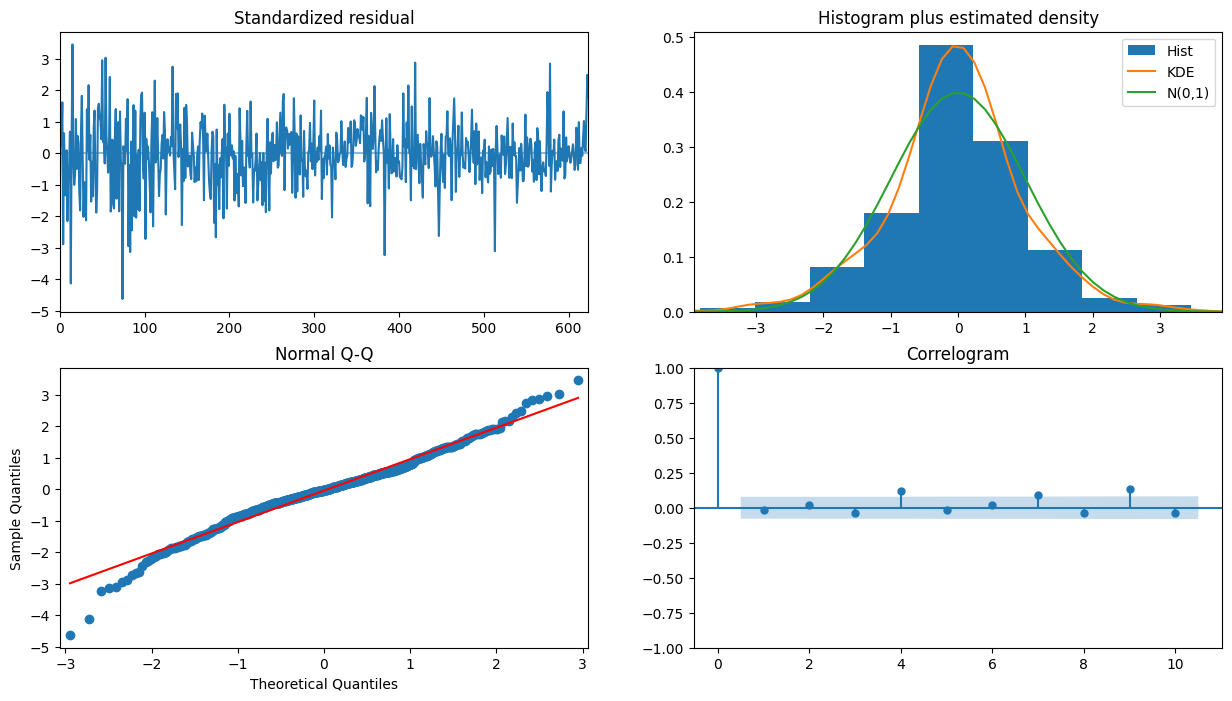

In [ ]:
from pmdarima import auto_arima
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=5,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=True,   # No Seasonality
                      start_P=0,
                      D=0,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_data, order=(0,1,0), seasonal_order=(1,0,1,5))
fitted = model.fit()
print(fitted.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                               Price   No. Observations:                  625
Model:             SARIMAX(0, 1, 0)x(1, 0, [1], 5)   Log Likelihood               -2224.933
Date:                             Sun, 02 Nov 2025   AIC                           4455.866
Time:                                     06:14:12   BIC                           4469.174
Sample:                                          0   HQIC                          4461.037
                                             - 625                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L5        0.8718      0.072     12.044      0.000       0.730       1.014
ma.S.L5       -0.9271      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


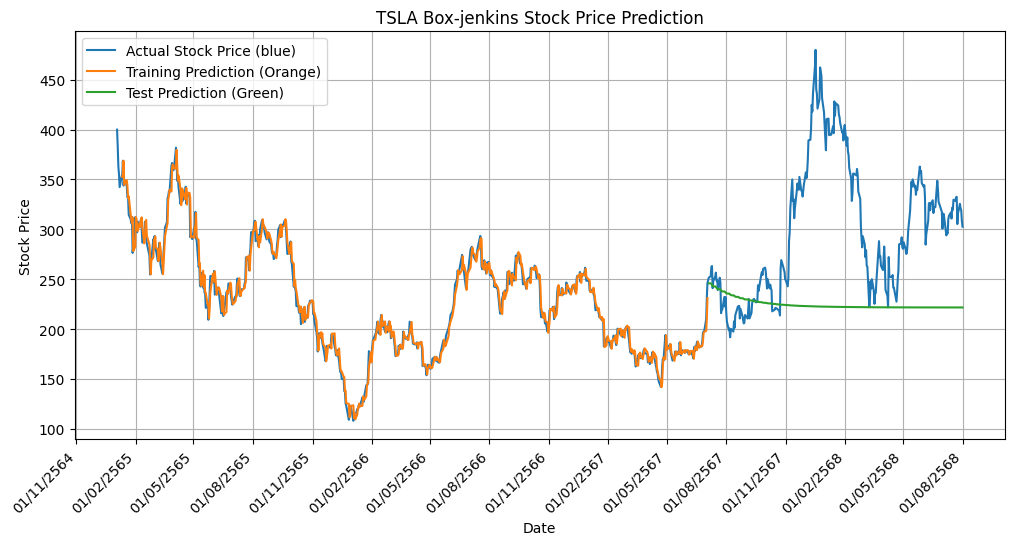

In [ ]:
# Forecast
# Only get the forecast values as retrieving se and conf is causing issues in this environment
fc = fitted.forecast(len(test_data))

# 4) ทำนายในชุด Train
#    ใช้ start/end ให้ครอบคลุม train index
train_pred = fitted.predict(start=train_data.index[3], end=train_data.index[-1], typ='levels')

# 5) ทำนายในชุด Test
test_pred = pd.Series(fc.values, index=test_data.index)

# ----------------------------------------------------
# Plot รวม train/test
# ----------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df,label='Actual Stock Price (blue)')
plt.plot(train_pred, label='Training Prediction (Orange)')
plt.plot(test_pred, label='Test Prediction (Green)')

plt.title('TSLA Box-jenkins Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)

# ---------------------------
# Format วันที่เป็น วัน/เดือน/ปี
# ---------------------------
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)

plt.show()

In [ ]:
print(test_pred[-30:])

Date
2025-06-20    221.717373
2025-06-23    221.717230
2025-06-24    221.716664
2025-06-25    221.715137
2025-06-26    221.713635
2025-06-27    221.713079
2025-06-30    221.712955
2025-07-01    221.712461
2025-07-02    221.711130
2025-07-03    221.709821
2025-07-07    221.709336
2025-07-08    221.709228
2025-07-09    221.708797
2025-07-10    221.707637
2025-07-11    221.706495
2025-07-14    221.706072
2025-07-15    221.705978
2025-07-16    221.705603
2025-07-17    221.704591
2025-07-18    221.703596
2025-07-21    221.703227
2025-07-22    221.703145
2025-07-23    221.702818
2025-07-24    221.701936
2025-07-25    221.701068
2025-07-28    221.700747
2025-07-29    221.700675
2025-07-30    221.700390
2025-07-31    221.699621
2025-08-01    221.698865
dtype: float64


In [ ]:
cal_error(train_data[3:],train_pred,test_data,test_pred)

Train --> RMSE: 8.55, MAE: 6.27, MAPE: 2.79%
Test --> RMSE: 100.68, MAE: 78.16, MAPE: 23.05%


In [ ]:
# --- Function to Prepare Dataset for ANN, LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:
##################################
##                              ##
##            LSTM              ##
##                              ##
##################################

In [ ]:
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
import time #helper libraries

Training model... This might take a moment.
Model training completed in 91.25 seconds.
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Test predictions exported to lstm_result.csv


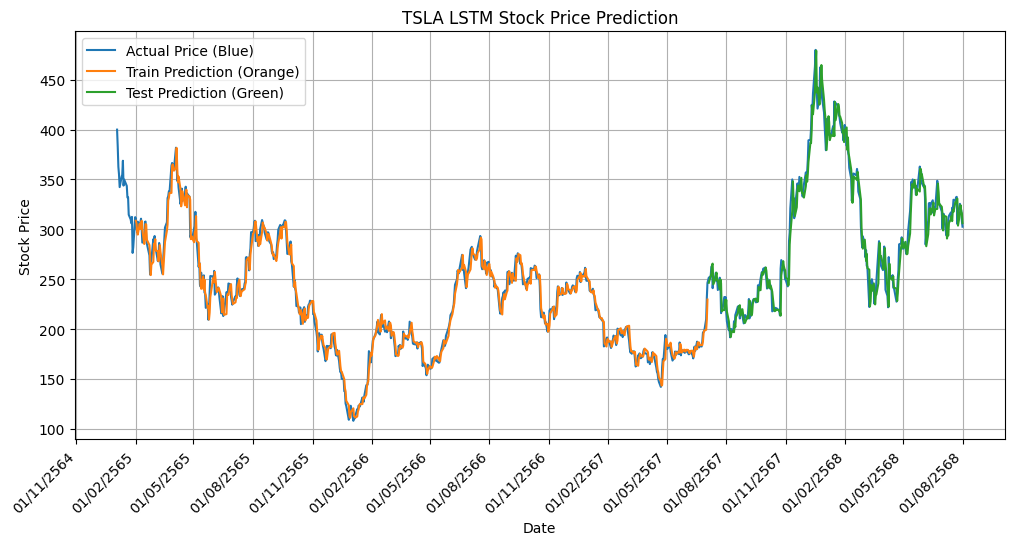

In [ ]:
# --- Configuration ---
look_back = 20 # Reduced Timestep for LSTM to ensure test data availability

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(url)
except FileNotFoundError:
    print(f"Error: File not found at {url}. Please ensure the file is uploaded.")
    exit()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df = df.sort_values(by=df.columns[0], ascending=True).reset_index(drop=True)

# take close price column (index 1 for 'Price' in this file structure)
# Assuming 'Price' is the 2nd column (index 1)
all_y = df[df.columns[1]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train = dataset[:train_size, :]
test = dataset[train_size-look_back:, :]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train)
    testPredictPlot[test_start_index:] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(df[df.columns[0]], scaler.inverse_transform(dataset), label='Actual Price (Blue)') # Actual/Baseline
plt.plot(df[df.columns[0]], trainPredictPlot, label='Train Prediction (Orange)') # Train prediction
if test_data_available:
    plt.plot(df[df.columns[0]], testPredictPlot, label='Test Prediction (Green)') # Test prediction
    plt.title('TSLA LSTM Stock Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.grid(True)

    # ---------------------------
    # Format วันที่เป็น วัน/เดือน/ปี
    # ---------------------------
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
    plt.gcf().autofmt_xdate()
    plt.xticks(rotation=45)

    plt.show()
else:
    plt.title('LSTM Stock Price Prediction (No Test Data for Plot)')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.grid(True)

    # ---------------------------
    # Format วันที่เป็น วัน/เดือน/ปี
    # ---------------------------
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
    plt.gcf().autofmt_xdate()
    plt.xticks(rotation=45)

    plt.show()

In [ ]:
print(testPredict[-30:])

[[320.2794 ]
 [320.45358]
 [345.95422]
 [337.1645 ]
 [324.71603]
 [324.9187 ]
 [322.55563]
 [315.78024]
 [298.9056 ]
 [313.73386]
 [312.63824]
 [290.79358]
 [295.49078]
 [293.8237 ]
 [306.40814]
 [310.03537]
 [313.41965]
 [308.22998]
 [319.45532]
 [317.4362 ]
 [327.30255]
 [326.39294]
 [329.99014]
 [330.7632 ]
 [303.73175]
 [315.31332]
 [324.13373]
 [318.0179 ]
 [316.18665]
 [306.25104]]


In [ ]:
cal_error(trainY[:,0], trainPredict[:,0], testY[:,0], testPredict[:,0])

Train --> RMSE: 8.32, MAE: 6.16, MAPE: 2.77%
Test --> RMSE: 13.20, MAE: 9.77, MAPE: 3.30%


In [ ]:
##################################
##                              ##
##             ANN              ##
##                              ##
##################################

Training ANN model... This might take a moment.
Model training completed in 56.66 seconds.
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


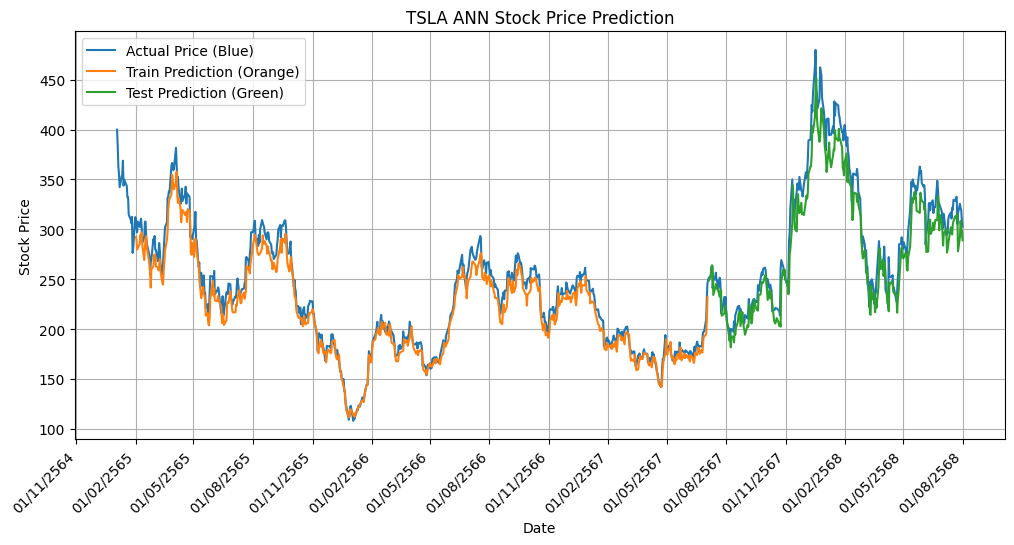

In [ ]:
# --- Configuration ---
look_back = 20  # จำนวนวันย้อนหลังที่ใช้เป็น input

# --- Load and Preprocess Data ---
try:
    df = read_csv(url)
except FileNotFoundError:
    print(f"Error: File not found at {url}.")
    exit()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df = df.sort_values(by=df.columns[0], ascending=True).reset_index(drop=True)

# Assuming 'Price' is the 2nd column (index 1)
all_y = df[df.columns[1]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# แบ่ง train/test (70/30)
train_size = int(len(dataset) * 0.7)
train = dataset[:train_size, :]
test = dataset[train_size - look_back:, :]

# สร้างชุดข้อมูล X, y
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

if testX.shape[0] > 0:
    test_data_available = True
else:
    print("Test dataset too small to create sequences with the given look_back.")
    test_data_available = False

# --- Build ANN Model ---
model = Sequential()
model.add(Input(shape=(look_back,)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # Output node เดียวสำหรับพยากรณ์ราคา

model.compile(loss='mse', optimizer='adam')

# --- Train Model ---
print("Training ANN model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Predict ---
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])

# --- Inverse Transform ---
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1))
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])

# --- เตรียมวันที่สำหรับ train/test ---
dates = df['Date'].values
dates_train = dates[look_back:len(trainPredict)+look_back]
dates_test = dates[train_size:]

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(dates, scaler.inverse_transform(dataset), label='Actual Price (Blue)')
plt.plot(dates_train, trainPredict, label='Train Prediction (Orange)')
if test_data_available:
    plt.plot(dates_test, testPredict, label='Test Prediction (Green)')
plt.title('TSLA ANN Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)

# ---------------------------
# Format วันที่เป็น วัน/เดือน/ปี
# ---------------------------
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)

plt.show()

In [ ]:
print(testPredict[-30:])

[[309.38968]
 [309.09164]
 [333.32803]
 [324.33252]
 [298.9823 ]
 [314.3672 ]
 [306.21286]
 [297.49408]
 [283.75815]
 [295.42007]
 [300.68665]
 [276.6935 ]
 [280.0371 ]
 [284.67245]
 [290.53   ]
 [301.95462]
 [296.96848]
 [294.8901 ]
 [305.14822]
 [308.23578]
 [313.2117 ]
 [311.62698]
 [314.467  ]
 [315.17902]
 [277.91486]
 [292.32883]
 [308.33997]
 [301.33047]
 [299.02014]
 [288.99203]]


In [ ]:
cal_error(trainY[:,0], trainPredict[:,0], testY[:,0], testPredict[:,0])

Train --> RMSE: 11.66, MAE: 9.31, MAPE: 3.89%
Test --> RMSE: 21.33, MAE: 17.12, MAPE: 5.52%


In [ ]:
##################################
##                              ##
##             CNN              ##
##                              ##
##################################

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import random
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [ ]:
# ---------------------------
# ฟังก์ชันสร้าง window
# ---------------------------
def create_dataset(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0353 - val_loss: 0.0109
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0054
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0027
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0025
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 8/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.9846e-04 - val_loss: 0.0022
Epoch 9/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.3722e-04 - val_loss: 0.0021
Epoch 10/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.9095e-04 - val_loss: 0.0020
Epoch 11/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5074e-04 - val_loss: 0.0019
Epoch 12/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

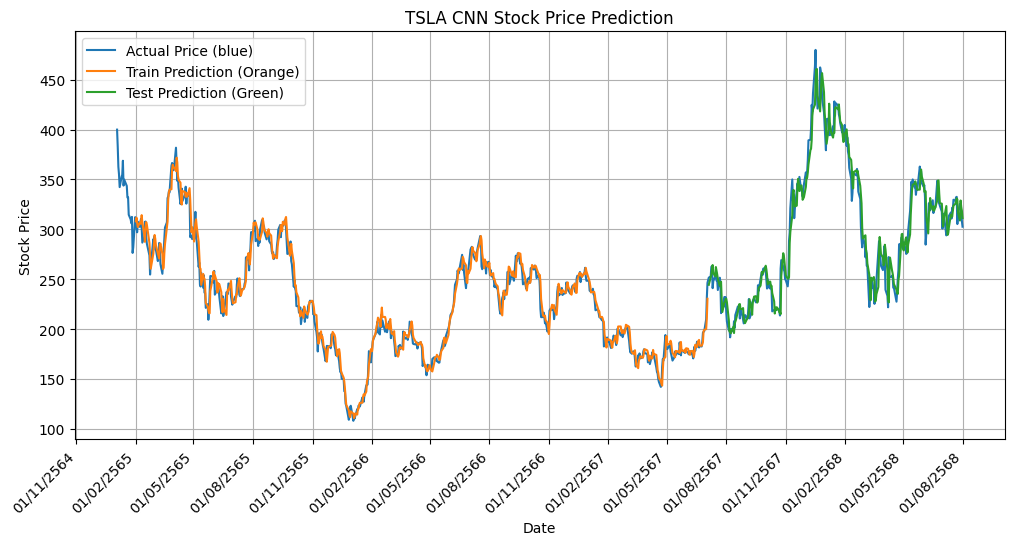

In [ ]:
# ---------------------------
# โหลดชุดข้อมูล
# ---------------------------
df = pd.read_csv(url)
df = df[['Date', 'Price']]  # เลือกเฉพาะวันที่ + ราคาปิด
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')  # เรียงวันที่

# ---------------------------
# Normalize ให้อยู่ระหว่าง 0-1
# ---------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Price'].values.reshape(-1, 1))
# ------------------------------------------------------
# กำหนดขนาด window_size (ใช้ข้อมูลย้อนหลัง 20 วัน)
# ------------------------------------------------------
window_size = 20

# -------------------------------------
# แบ่ง train/test (70/30)
# -------------------------------------
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - window_size:]

# ---------------------------
# สร้างชุดข้อมูล
# ---------------------------
X_train, y_train = create_dataset(train_data, window_size)
X_test, y_test = create_dataset(test_data, window_size)

# -------------------------------------------
# Reshape ให้เป็น [samples, timesteps, features]
# -------------------------------------------
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ---------------------------
# สร้าง CNN Model
# ---------------------------
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, 1)), MaxPooling1D(pool_size=2), Flatten(), Dense(32, activation='relu'), Dense(1)])

model.compile(optimizer='adam', loss='mse')

# ---------------------------
# Train Model
# ---------------------------
history = model.fit(X_train, y_train, epochs = 50, batch_size = 8, validation_data=(X_test, y_test))

# ---------------------------
# Evaluate & Predict
# ---------------------------
pred_train = model.predict(X_train)
pred_train = scaler.inverse_transform(pred_train)
actual_train = scaler.inverse_transform(y_train.reshape(-1, 1))

pred_test = model.predict(X_test)
pred_test = scaler.inverse_transform(pred_test)
actual_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---------------------------
# Flatten เพื่อให้ง่ายต่อการ plot
# ---------------------------
pred_train = pred_train.flatten()
actual_train = actual_train.flatten()
pred_test = pred_test.flatten()
actual_test = actual_test.flatten()

# ---------------------------
# ดึงวันที่
# ---------------------------
dates_train = df['Date'].values[window_size:len(pred_train)+look_back]
dates_test = df['Date'].values[train_size:]

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label = 'Actual Price (blue)')

# ---------------------------
# Plot train pred
# ---------------------------
plt.plot(dates_train, pred_train, label='Train Prediction (Orange)')

# ---------------------------
# Plot test pred
# ---------------------------
plt.plot(dates_test, pred_test, label="Test Prediction (Green)")

plt.legend()
plt.title("TSLA CNN Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)

# ---------------------------
# Format วันที่เป็น วัน/เดือน/ปี
# ---------------------------
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)

# ---------------------------
# แสดงกราฟ
# ---------------------------
plt.show()

In [ ]:
print(pred_test[-30:])

[321.88058 329.3475  348.78134 349.0084  335.91315 326.11124 325.7568
 313.61176 302.94534 309.54034 323.36087 305.09595 294.39383 296.35544
 302.44382 314.71783 314.129   312.70035 318.4672  323.84552 325.54456
 328.39642 330.96164 329.94327 316.91382 308.86908 328.90845 322.5123
 318.44406 311.2546 ]


In [ ]:
cal_error(actual_train, pred_train, actual_test, pred_test)

Train --> RMSE: 8.74, MAE: 6.60, MAPE: 2.96%
Test --> RMSE: 14.47, MAE: 10.69, MAPE: 3.63%
